# 25 — Default Risk Charge (DRC) for the correlation trading portfolio

Follow the complete path from gross jump-to-default exposure to DRC capital.

CTP tranches and eligible index hedges use their own aggregation and cross-index treatment. Jump to Default (JTD) is the loss or gain if a reference name defaults immediately. The Hedge Benefit Ratio (HBR) limits short-position offset.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

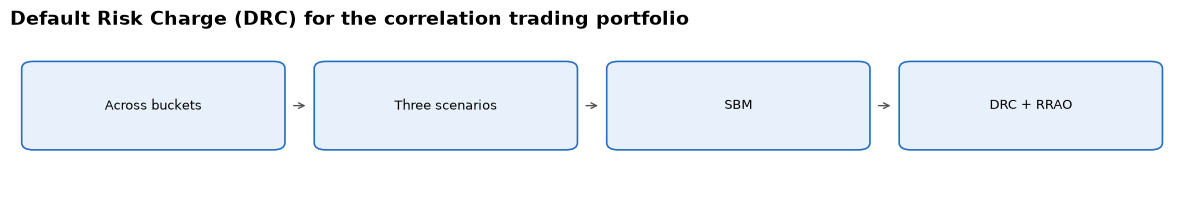

In [2]:
draw_flow(['Across buckets', 'Three scenarios', 'SBM', 'DRC + RRAO'],'Default Risk Charge (DRC) for the correlation trading portfolio',wrap_after=4)

Calculate gross JTD trade by trade, apply permitted netting, separate net long and short JTD, risk-weight both sides, and discount the short-side benefit through HBR.

$$HBR=\frac{\text{net long JTD}}{\text{net long JTD}+|\text{net short JTD}|}$$

$$DRC_b=\text{weighted long}-HBR\times|\text{weighted short}|$$

In [3]:
gross=pd.read_csv(RUN/'11_drc_gross_jtd.csv'); net=pd.read_csv(RUN/'12_drc_net_jtd.csv'); buckets=pd.read_csv(RUN/'13_drc_bucket_results.csv')
gross_view=gross[gross.drc_class=='SECURITISATION_CTP'].copy(); net_view=net[net.drc_class=='SECURITISATION_CTP'].copy(); bucket_view=buckets[buckets.drc_class=='SECURITISATION_CTP'].copy()
gross_view=gross_view.dropna(axis=1,how='all'); net_view=net_view.dropna(axis=1,how='all'); bucket_view=bucket_view.dropna(axis=1,how='all')
print('1. Gross trade-level JTD'); display(percent_columns(crore_table(gross_view,['gross_jtd']),['risk_weight']).fillna('Not applicable'))
print('2. Net JTD after permitted offsetting'); display(percent_columns(crore_table(net_view,['net_jtd']),['risk_weight']).fillna('Not applicable'))
print('3. HBR and risk-weighted bucket charge'); display(crore_table(bucket_view,['net_long_jtd','net_short_jtd','weighted_long','weighted_short','capital']))
print(f"Capital for this DRC class: INR {bucket_view.capital.sum()/INR_CRORE:,.4f} crore")

1. Gross trade-level JTD


,trade_id,drc_class,bucket,obligor,rating,seniority,maturity_scale,lgd,Gross Jtd (INR crore),Risk Weight (%),attachment,detachment
26,T01,SECURITISATION_CTP,CDX_IG,CDX_IG_S42_3_7,BBB,SENIOR,1.0000,0.0000,9.7945,98.0277,0.0300,0.0700
27,T02,SECURITISATION_CTP,CDX_IG,CDX_IG_S42,BBB,SENIOR,1.0000,0.0000,-8.3399,6.0000,0.0000,1.0000


2. Net JTD after permitted offsetting


,drc_class,bucket,obligor,rating,Net Jtd (INR crore),Risk Weight (%),attachment,detachment
16,SECURITISATION_CTP,CDX_IG,CDX_IG_S42,BBB,-8.3399,6.0000,0.0000,1.0000
17,SECURITISATION_CTP,CDX_IG,CDX_IG_S42_3_7,BBB,9.7945,98.0277,0.0300,0.0700


3. HBR and risk-weighted bucket charge


,drc_class,bucket,Net Long Jtd (INR crore),Net Short Jtd (INR crore),hbr,Weighted Long (INR crore),Weighted Short (INR crore),Capital (INR crore)
3,SECURITISATION_CTP,CDX_IG,9.7945,-8.3399,0.5401,9.6013,0.5004,9.3310


Capital for this DRC class: INR 9.3310 crore


The visual below uses the calculated rows shown above.

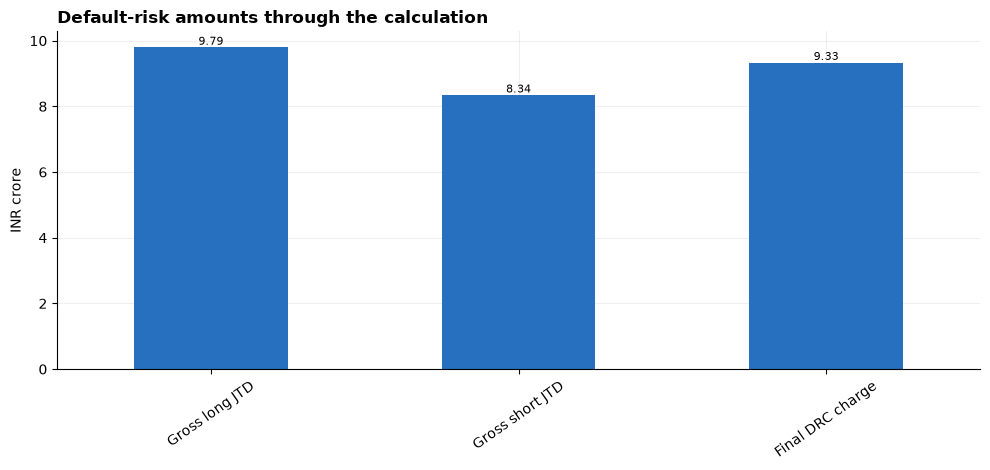

In [4]:
stages=pd.Series({'Gross long JTD':gross_view.loc[gross_view.gross_jtd>0,'gross_jtd'].sum(),
                          'Gross short JTD':abs(gross_view.loc[gross_view.gross_jtd<0,'gross_jtd'].sum()),
                          'Final DRC charge':bucket_view.capital.sum()})
bar_crore(stages,'Default-risk amounts through the calculation')

The charge remains separate from the other DRC classes and from CSR spread risk in SBM.